In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
cust = pd.read_csv("Mail Customers.csv")
cust

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
cust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CustomerID          200 non-null    int64 
 1   Genre               200 non-null    object
 2   Age                 200 non-null    int64 
 3   Annual_Income_(k$)  200 non-null    int64 
 4   Spending_Score      200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


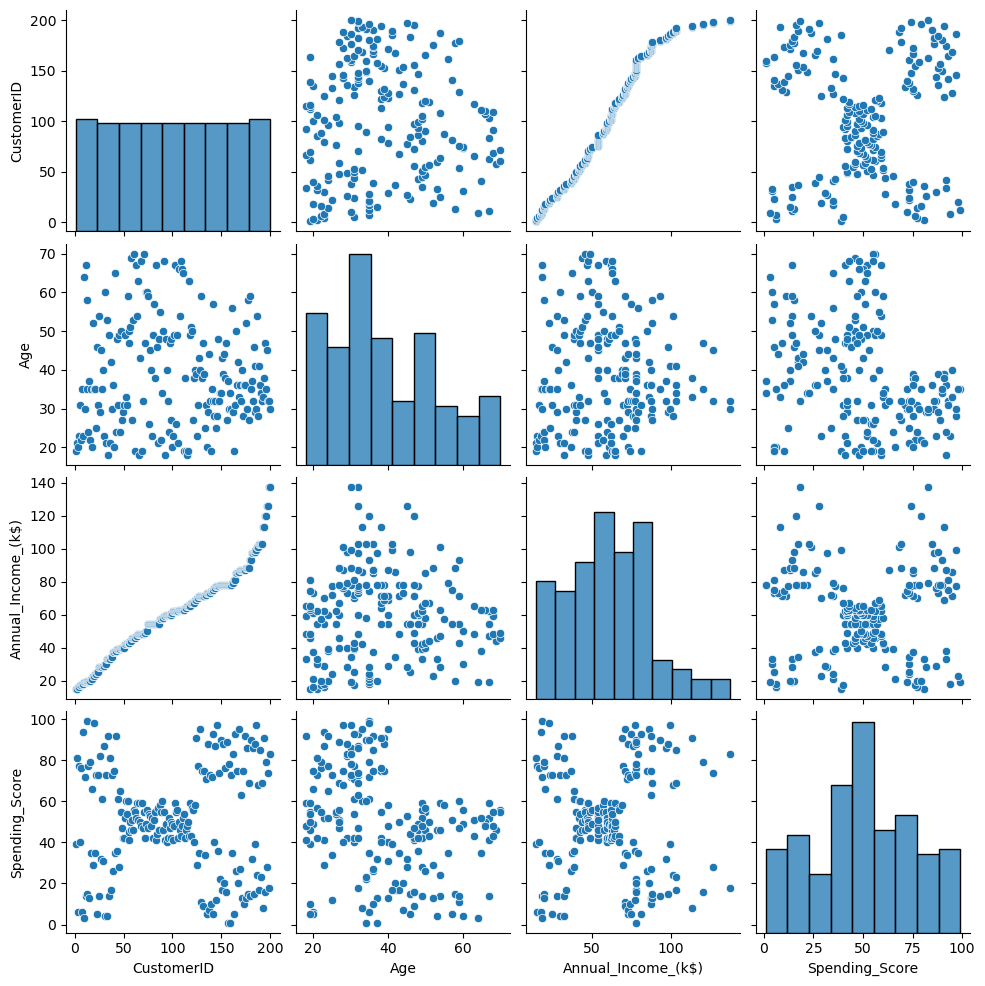

In [28]:
sns.pairplot(cust)

## Model Development

In [5]:
cust.head()

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
cust.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score'], dtype='object')

In [7]:
X_features = cust[['Age', 'Annual_Income_(k$)', 'Spending_Score']]
X_features

,Age,Annual_Income_(k$),Spending_Score
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


In [8]:
cust.describe()

,CustomerID,Age,Annual_Income_(k$),Spending_Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Standardize Features

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
#instantiate the scalar
scaler = StandardScaler()

In [11]:
scaled_features = scaler.fit_transform(X_features)
scaled_features

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992],
       [-1.20926872, -1.66266033,  1.00159627],
       [-0.27630176, -1.62449091, -1.71591298],
       [-1.13750203, -1.62449091,  1.70038436],
       [ 1.80493225, -1.58632148, -1.83237767],
       [-0.6351352 , -1.58632148,  0.84631002],
       [ 2.02023231, -1.58632148, -1.4053405 ],
       [-0.27630176, -1.58632148,  1.89449216],
       [ 1.37433211, -1.54815205, -1.36651894],
       [-1.06573534, -1.54815205,  1.04041783],
       [-0.13276838, -1.54815205, -1.44416206],
       [-1.20926872, -1.54815205,  1.11806095],
       [-0.27630176, -1.50998262, -0.59008772],
       [-1.3528021 , -1.50998262,  0.61338066],
       [ 0.94373197, -1.43364376, -0.82301709],
       [-0.27630176, -1.43364376,  1.8556706 ],
       [-0.27630176, -1.39547433, -0.590

In [12]:
pd.DataFrame(scaled_features, columns = X_features.columns)

,Age,Annual_Income_(k$),Spending_Score
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980
...,...,...,...
195,-0.276302,2.268791,1.118061
196,0.441365,2.497807,-0.861839
197,-0.491602,2.497807,0.923953
198,-0.491602,2.917671,-1.250054


## Elbow method of determining the K value

In [38]:
from sklearn.cluster import KMeans 

In [14]:
inertia = []
for k in range (1, 11):
    #initialize model
    km = KMeans(n_clusters = k, random_state = 42)
    # fit the model
    km.fit(scaled_features)
    # save the inertia_ to the list above
    inertia.append(km.inertia_)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [15]:
inertia

[599.9999999999999,
 389.3861889564372,
 295.4562449213556,
 205.22514747675913,
 169.89149793438582,
 134.35277477401493,
 121.38935022502872,
 113.72723000071338,
 102.13623844329254,
 92.55027231838785]

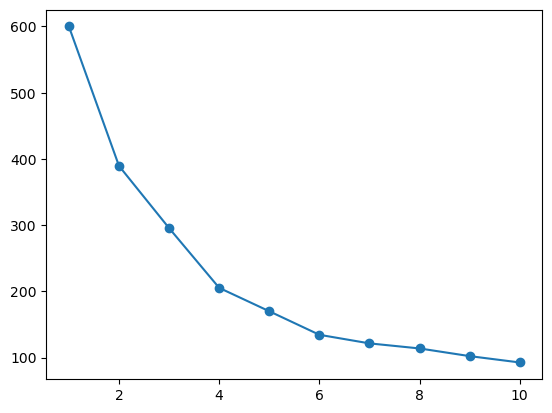

In [16]:
plt.plot(range(1,11), inertia, marker = 'o')

In [54]:
km = KMeans(n_clusters = 5, random_state = 42)
km.fit(scaled_features)

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



KMeans(n_clusters=5, random_state=42)

In [18]:
km.labels_

array([2, 2, 3, 2, 2, 2, 3, 2, 0, 2, 0, 2, 0, 2, 3, 2, 3, 2, 0, 2, 3, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 3, 2, 0, 2, 0, 2,
       0, 2, 0, 3, 3, 3, 0, 2, 3, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 0, 0, 3,
       0, 0, 3, 3, 0, 0, 0, 0, 0, 3, 0, 3, 3, 0, 0, 3, 0, 0, 3, 0, 0, 3,
       3, 0, 0, 3, 0, 3, 3, 3, 0, 3, 0, 3, 3, 0, 0, 3, 0, 3, 0, 0, 0, 0,
       0, 3, 3, 3, 3, 3, 0, 0, 0, 0, 3, 3, 1, 1, 3, 1, 4, 1, 4, 1, 4, 1,
       3, 1, 3, 1, 4, 1, 3, 1, 4, 1, 3, 1, 3, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 3, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1,
       4, 1], dtype=int32)

In [33]:
cust['Clusters'] = km.labels_
cust

,CustomerID,Genre,Age,Annual_Income_(k$),Spending_Score,Clusters
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,3
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,4
197,198,Male,32,126,74,1
198,199,Male,32,137,18,4


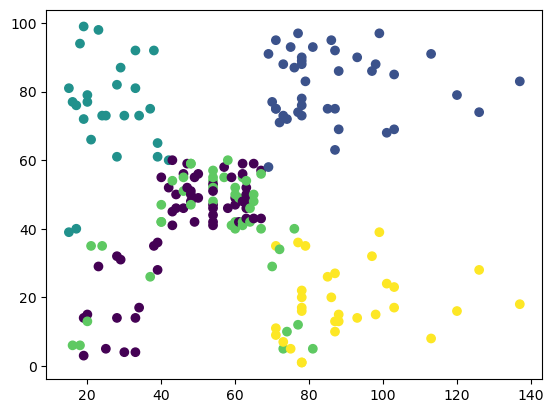

In [34]:
plt.scatter(cust['Annual_Income_(k$)'], cust['Spending_Score'], c = cust['Clusters'])

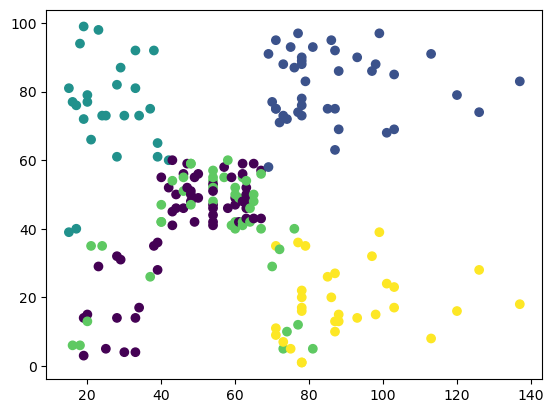

In [21]:
#specified the color here
plt.scatter(cust['Annual_Income_(k$)'], cust['Spending_Score'], c = cust['Clusters'], cmap = 'viridis')

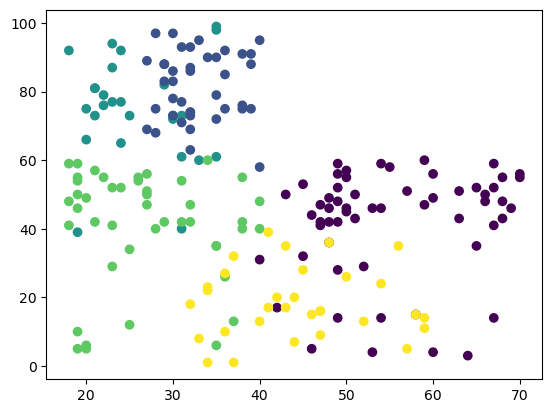

In [35]:
plt.scatter(cust['Age'], cust['Spending_Score'], c = cust['Clusters'])

In [ ]:
import plotly.express as px

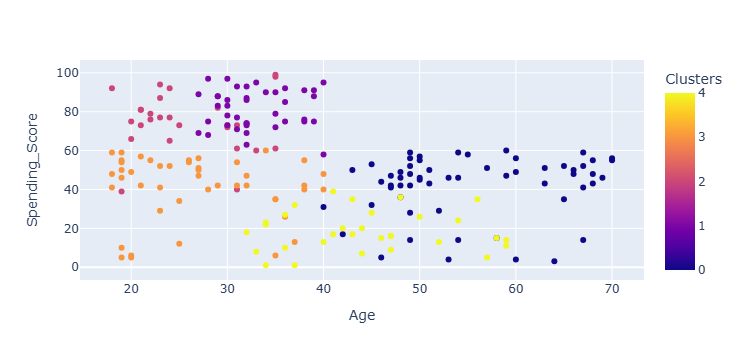

In [36]:
px.scatter(cust, "Age", "Spending_Score", color = "Clusters")

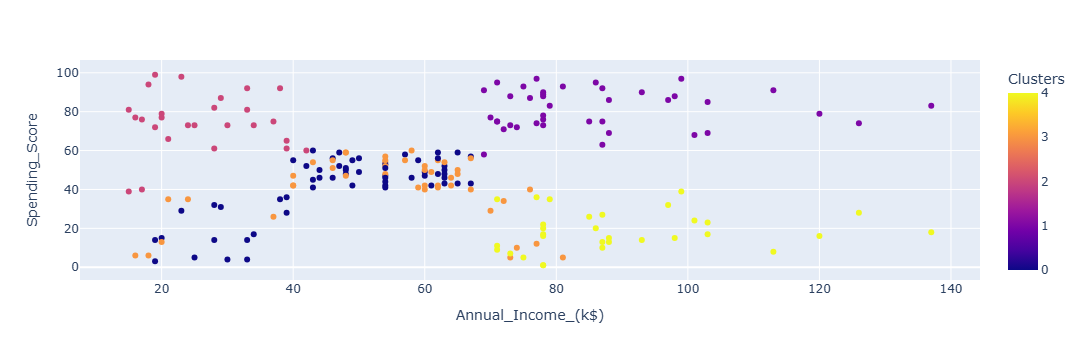

In [25]:
px.scatter(cust, "Annual_Income_(k$)", "Spending_Score", color = "Clusters")

## CONTINUOUS ANALYSIS

In [41]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_features, km.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.40846873777345605


In [55]:
centroids = km.cluster_centers_

centroid_df = pd.DataFrame(centroids, columns=X_features.columns)

centroid_df['Cluster'] = centroid_df.index
print(centroid_df)

        Age  Annual_Income_(k$)  Spending_Score  Cluster
0  1.178830           -0.493886       -0.329716        0
1 -0.428806            0.974847        1.216085        1
2 -0.938764           -1.314731        0.956802        2
3 -0.869573           -0.238517       -0.360609        3
4  0.397379            1.115089       -1.231270        4


In [56]:
centroids_original = scaler.inverse_transform(km.cluster_centers_)

centroid_df = pd.DataFrame(centroids_original, columns=X_features.columns)

centroid_df['Cluster'] = centroid_df.index
print(centroid_df)

         Age  Annual_Income_(k$)  Spending_Score  Cluster
0  55.275862           47.620690       41.706897        0
1  32.875000           86.100000       81.525000        1
2  25.769231           26.115385       74.846154        2
3  26.733333           54.311111       40.911111        3
4  44.387097           89.774194       18.483871        4
